In [1]:
from helptools import register_user, login_user, identify, login_user_image
from PersonsDataset import PersonDataset
import matplotlib.image as mpimg
import matplotlib.pyplot as plt
from dotenv import load_dotenv
from faker import Faker
import itertools as it
import numpy as np
import random
import tqdm
import cv2

In [2]:
load_dotenv()

True

In [3]:
train_dataset = PersonDataset("../data/train")

In [4]:
# import httpx
# import os

In [5]:
# timeout = httpx.Timeout(300)

# async with httpx.AsyncClient(timeout=timeout) as client:
#     response = await client.post(
#             "http://localhost:8000/get_token",
#             params={
#                 "username": os.getenv("API_USER"),
#                 "password": os.getenv("API_PASSWORD")
#             }
#         )

In [6]:
fake = Faker()
subset = list(it.islice(train_dataset, 250))
train_check = {}
id_dict = {}

In [7]:
for images, person_id in tqdm.tqdm(subset):
    first_name = fake.unique.first_name()
    last_name = fake.unique.last_name()

    response = await register_user(
        images=images, first_name=first_name, last_name=last_name
    )
    if response.status_code == 200:
        server_id = response.json().get("id")
        if server_id is not None:
            train_check[server_id] = images[:2]
            id_dict[server_id] = person_id

100%|██████████| 250/250 [23:35<00:00,  5.66s/it]


In [8]:
ids = list(train_check.keys())

In [9]:
FR = 0  # False reject
FA = 0  # False acceptance
TA = 0  # True acceptance
TR = 0  # True reject

In [10]:
len(train_check)

249

In [11]:
FR_example = None
FA_example = None

In [ ]:
for person_id, images in tqdm.tqdm(train_check.items()):
    img1, img2 = images
    r = await login_user(img1, person_id)
    s = r.json().get('success')
    if s is not None:
        if s:
            TA += 1
        else:
            if FR == 0:
                FR_example = ((subset[id_dict[person_id]][0][-1], img1))
            FR += 1
            

    other_id = random.choice(ids)
    while other_id == person_id:
        other_id = random.choice(ids)

    r = await login_user(img2, other_id)
    s = r.json().get('success')
    if s is not None:
        if s:
            if FA == 0:
                FA_example = ((train_check[person_id][0], img2))
            FA += 1
        else:
                TR += 1

100%|██████████| 249/249 [11:57<00:00,  2.88s/it]


**ZAD 1**

dodanie 200 osób do systemu

FAR i FRR na 400 przykładach sprawdzenie i autoryzacja do siebie i próba ataku

In [13]:
print(f"FAR: {FA/(FA+TR)} \nFRR: {FR/(FR+TA)}")

FAR: 0.004291845493562232 
FRR: 0.03404255319148936


In [25]:
test = (FR_example[0], FR_example[1][1])

In [29]:
FR_example

(WindowsPath('../data/train/n000024/0005_02.jpg'),
 WindowsPath('../data/train/n000024/0001_01.jpg'))

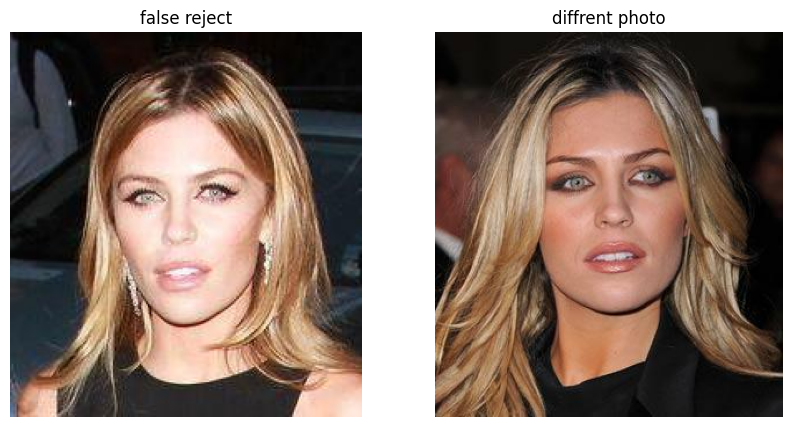

In [31]:
if FR_example is not None:

    rejected_img, diffrent_img = FR_example
    
    img1 = mpimg.imread(rejected_img)
    img2 = mpimg.imread(diffrent_img)
    
    fig, axes = plt.subplots(1,2, figsize=(10,5))
    axes[0].imshow(img1)
    axes[0].axis('off')
    axes[0].set_title('false reject')

    axes[1].imshow(img2)
    axes[1].axis('off')
    axes[1].set_title('diffrent photo')

    plt.show()

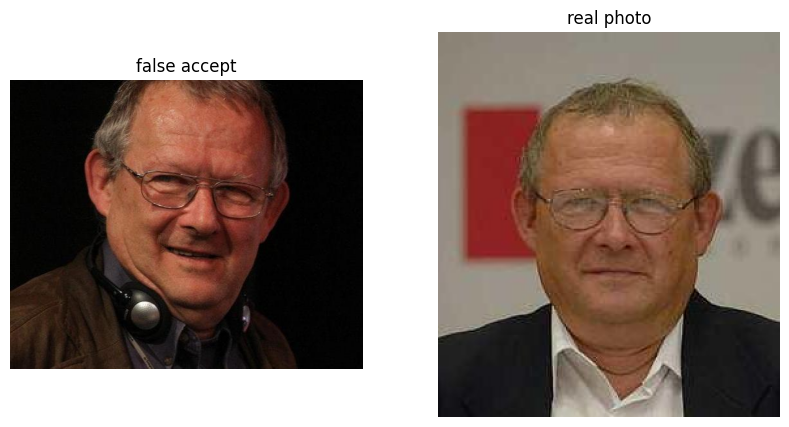

In [34]:
if FA_example is not None:

    accepted_img, real_img = FA_example
    
    img1 = mpimg.imread(accepted_img)
    img2 = mpimg.imread(real_img)
    
    fig, axes = plt.subplots(1,2, figsize=(10,5))
    axes[0].imshow(img1)
    axes[0].axis('off')
    axes[0].set_title('false accept')

    axes[1].imshow(img2)
    axes[1].axis('off')
    axes[1].set_title('real photo')

    plt.show()

In [35]:
val_dataset = PersonDataset("../data/val")

In [ ]:
# fake = Faker()
# subset = list(it.islice(train_dataset, 60))
# possible_attacks = 0
# for images, person_id in tqdm.tqdm(subset):

#     responses = []

#     for image in images[:2]:
#         responses += [await identify(image) for image in images]

#     contents = list(map(lambda resp: resp.json().get("found", []), responses))

#     possible_attacks += len(set(sum(contents, [])))

**ZAD 2 dodatek**

ataki przy autoryzacji 1:N

In [ ]:
# possible_attacks

In [65]:
A = 0
R = 0

In [66]:
examples = []

In [67]:
val_subset = list(it.islice(val_dataset, 60))

In [68]:
for images, person_id in tqdm.tqdm(val_subset):
    for img in images:

        attacked_id = random.choice(ids)

        r = await login_user(img, attacked_id)
        s = r.json().get('success')
        if s is not None:
            if s:
                examples.append((attacked_id, person_id))
                A += 1
            else:
                R += 1

100%|██████████| 60/60 [07:17<00:00,  7.29s/it]


**ZAD 2**

120 prób autoryzacji zdjęciami osób z poza puli treningowej

In [69]:
print(f"FA:{A} \nTR:{R} \nFAR(with previous results):{(FA+A)/(FA+A+R+TR)}")

FA:1 
TR:274 
FAR(with previous results):0.003937007874015748


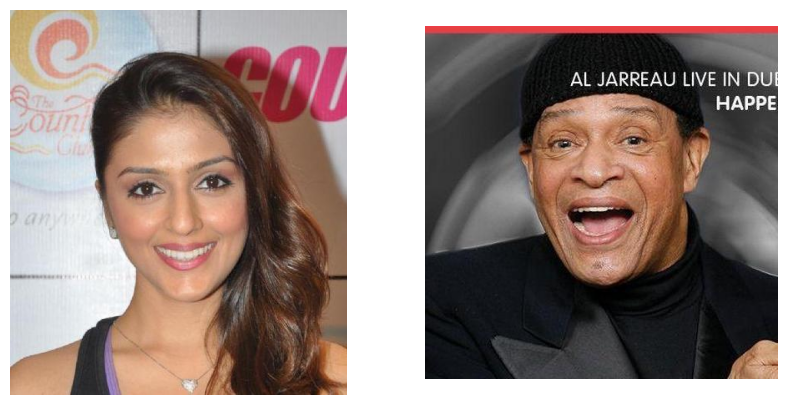

In [70]:
for example in examples[:2]:
    attacked_id, person_id = example
    attacked_img = train_check[attacked_id][0]
    person = subset[person_id]
    images, check_id = person
    if check_id != person_id:
        raise Exception

    person_image = images[0]
    
    img1 = mpimg.imread(person_image)
    img2 = mpimg.imread(attacked_img)
    
    fig, axes = plt.subplots(1,2, figsize=(10,5))
    axes[0].imshow(img1)
    axes[0].axis('off')

    axes[1].imshow(img2)
    axes[1].axis('off')

    plt.show()

In [71]:
def add_gaussian_noise_psnr(img_path, psnr_pairs=[(50,80),(40,50),(30,40),(20,30),(10,20)]):
    img = cv2.imread(img_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    
    def psnr_to_std(img, target_psnr):
        mse = np.mean(img.astype(np.float32)**2) / (10**(target_psnr/10))
        return np.sqrt(mse)

    noisy_images = {}
    img_float = img.astype(np.float32)

    for (psnr_min, psnr_max) in psnr_pairs:
        target_psnr = np.random.uniform(psnr_min, psnr_max)
        std = psnr_to_std(img_float, target_psnr)
        
        gauss = np.random.normal(0, std, img.shape).astype(np.float32)
        noisy_img = img_float + gauss
        noisy_img = np.clip(noisy_img, 0, 255).astype(np.uint8)

        image_bgr = cv2.cvtColor(noisy_img, cv2.COLOR_RGB2BGR)

        success, encoded_image = cv2.imencode('.png', image_bgr)
        
        noisy_images[(psnr_min, psnr_max)] = (encoded_image.tobytes())

    return noisy_images

In [72]:
base_dict = {(50,80): 0,(40,50): 0,(30,40): 0,(20,30): 0,(10,20): 0}
FR_noise = base_dict.copy()  # False reject
FA_noise = base_dict.copy()  # False acceptance
TA_noise = base_dict.copy()  # True acceptance
TR_noise = base_dict.copy()  # True reject

In [73]:
max_F = 0
images_to_show = None

In [74]:
for person_id, images in tqdm.tqdm(list(train_check.items())[:20]):
    F = 0

    noisy_images = add_gaussian_noise_psnr(images[0])

    for k , img in noisy_images.items():
        r = await login_user_image(img, person_id, str(images[0]) + str(k))
        if r.status_code == 200:
            s = r.json().get('success')
            if s is not None:
                if s:
                    TA_noise[k] += 1
                else:
                    FR_noise[k] += 1
                    F += 1
        else:
            FR_noise[k] += 1
            F += 1

        other_id = random.choice(ids)
        while other_id == person_id:
            other_id = random.choice(ids)

        r = await login_user_image(img, other_id, str(images[0]) + str(k))
        if r.status_code == 200:
            s = r.json().get('success')
            if s is not None:
                if s:
                    FA_noise[k] += 1
                    F += 1
                else:
                    TR_noise[k] += 1
        else:
            TR_noise[k] += 1

    if F > max_F:
        max_F = F
        images_to_show = noisy_images

100%|██████████| 20/20 [05:33<00:00, 16.68s/it]


**ZAD 3**

porównanie wpływu szumu o różnej mocy na wyniki

In [75]:
for k in base_dict.keys():
    print(f"k \n FAR: {FA_noise[k]/(FA_noise[k]+TR_noise[k])} \n FRR:{FR_noise[k]/(FR_noise[k]+TA_noise[k])} \n")

k 
 FAR: 0.0 
 FRR:0.0 

k 
 FAR: 0.0 
 FRR:0.0 

k 
 FAR: 0.0 
 FRR:0.05555555555555555 

k 
 FAR: 0.0 
 FRR:0.0 

k 
 FAR: 0.0 
 FRR:0.0 



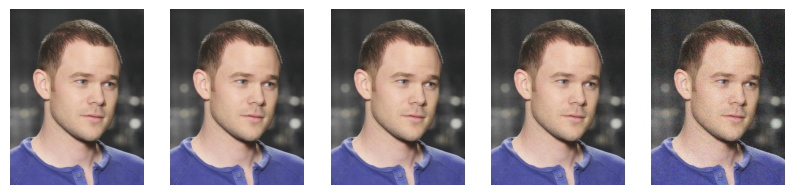

In [76]:
if images_to_show is not None:

    fig, axes = plt.subplots(1,5, figsize=(10,5))

    for image, ax in zip(images_to_show.values(), axes):
    
        nparr = np.frombuffer(image, np.uint8)
        img = cv2.imdecode(nparr, cv2.IMREAD_COLOR)
        img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        ax.imshow(img_rgb)
        ax.axis('off')

    plt.show()

In [ ]:
def change_luminance(img_path):
    img = cv2.imread(img_path)
    img_ycrcb = cv2.cvtColor(img, cv2.COLOR_BGR2YCrCb).astype(np.float32)
    Y, Cr, Cb = cv2.split(img_ycrcb)
    
    results = {}
    
    scale_factors = [0.5, 0.6, 0.75, 1.33, 1.5]
    for factor in scale_factors:
        Y_new = np.clip(Y * factor, 0, 255)
        img_new = cv2.merge([Y_new, Cr, Cb]).astype(np.uint8)
        img_bgr = cv2.cvtColor(img_new, cv2.COLOR_YCrCb2BGR)
        
        success, encoded_image = cv2.imencode('.png', img_bgr)

        if not success:
            print('error')

        results[f"scale_{factor:.2f}"] = (encoded_image.tobytes())
    
    add_values = [-100, -20, -10, 30]
    for val in add_values:
        Y_new = np.clip(Y + val, 0, 255)
        img_new = cv2.merge([Y_new, Cr, Cb]).astype(np.uint8)
        img_bgr = cv2.cvtColor(img_new, cv2.COLOR_YCrCb2BGR)

        success, encoded_image = cv2.imencode('.png', img_bgr)

        if not success:
            print('error')

        results[f"add_{val}"] = (encoded_image.tobytes())
    
    return results

In [78]:
base_dict = {f"scale_{factor:.2f}": 0 for factor in [0.5, 0.6, 0.75, 1.33, 1.5]}
base_dict.update({f"add_{val}": 0 for val in [-100, -20, -10, 30]})
FR_scale_y = base_dict.copy()  # False reject
FA_scale_y = base_dict.copy()  # False acceptance
TA_scale_y = base_dict.copy()  # True acceptance
TR_scale_y = base_dict.copy()  # True reject

In [79]:
max_F = 0
images_to_show = None

In [80]:
for person_id, images in tqdm.tqdm(list(train_check.items())[:20]):
    F = 0

    changed_images = change_luminance(images[0])

    for k, img in changed_images.items():
        r = await login_user_image(img, person_id, str(images[0]) + str(k))
        if r.status_code == 200:
            s = r.json().get('success')
            if s is not None:
                if s:
                    TA_scale_y[k] += 1
                else:
                    FR_scale_y[k] += 1
                    F += 1
        else:
            FR_scale_y[k] += 1
            F += 1

        other_id = random.choice(ids)
        while other_id == person_id:
            other_id = random.choice(ids)

        r = await login_user_image(img, other_id, str(images[0]) + str(k))
        if r.status_code == 200:
            s = r.json().get('success')
            if s is not None:
                if s:
                    FA_scale_y[k] += 1
                    F += 1
                else:
                    TR_scale_y[k] += 1
        else:
            TR_scale_y[k] += 1

    if F > max_F:
        max_F = F
        images_to_show = changed_images

100%|██████████| 20/20 [09:26<00:00, 28.31s/it]


**ZAD 4**

porównanie wpływu zmiany luminacji na wyniki

In [81]:
for k in base_dict.keys():
    print(f"FAR: {FA_scale_y[k]/(FA_scale_y[k]+TR_scale_y[k])} \n FRR:{FR_scale_y[k]/(FR_scale_y[k]+TA_scale_y[k])}")

FAR: 0.0 
 FRR:0.0
FAR: 0.0 
 FRR:0.0625
FAR: 0.0 
 FRR:0.0
FAR: 0.0 
 FRR:0.0
FAR: 0.0 
 FRR:0.0
FAR: 0.0 
 FRR:0.17647058823529413
FAR: 0.0 
 FRR:0.05263157894736842
FAR: 0.0 
 FRR:0.0
FAR: 0.0 
 FRR:0.0


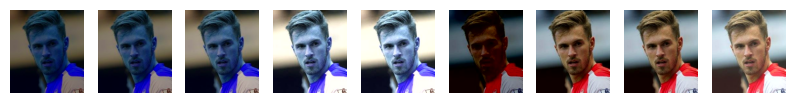

In [83]:
if images_to_show is not None:

    fig, axes = plt.subplots(1,9, figsize=(10,5))

    for image, ax in zip(images_to_show.values(), axes):
    
        nparr = np.frombuffer(image, np.uint8)
        img = cv2.imdecode(nparr, cv2.IMREAD_COLOR)
        img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        ax.imshow(img_rgb)
        ax.axis('off')

    plt.show()